# Assignment 2 — Evaluating the Impact of FOMC Communications on Asset Prices
**FRE-GY 7871 A · NLP and the Investment Process · Fall 2026**
Due: Tuesday, September 15, 2026, 11:59 PM

## Objective

Kevin Warsh became Chair of the Federal Reserve on **May 22, 2026**, succeeding Jerome Powell
(Chair since February 2018). This notebook:

1. Collects FOMC post-meeting statements, meeting minutes, and Chair speeches/testimony/press
   conferences from **February 2018 to the present**, from the official Federal Reserve website.
2. Scores the hawkish/dovish tone of each document with **two independent methods**:
   a hand-built monetary-policy word list, and **FinBERT** sentence-level sentiment.
3. Tracks tone over time and compares the **Powell era vs. the Warsh era**.
4. Validates market reactions by regressing the one-day change in four required indicators
   (DXY, 10Y–2Y Treasury spread, 1-year Treasury yield, Growth-minus-Value) on tone,
   controlling for the change in the 3-month T-bill yield (`DGS3MO`) so that tone is not
   credited with the rate decision itself.
5. Forecasts the **September 2026 FOMC meeting**: rate-decision probabilities, the probability
   the statement is more hawkish than the prior one, expected market reactions, and a
   position recommendation with an explicit falsification condition.

### Working principles (do not violate)
- The four required market outcomes are **DXY, 10Y–2Y spread, 1-year Treasury yield, and
  Growth-minus-Value** — **not** the S&P 500. `DGS3MO` is a **control**, not an outcome.
- Never invent missing market data or release timestamps — missing means missing.
- `WARSH_START_DATE` is **not** a placeholder: it is confirmed below from Federal Reserve and
  news sources as **2026-05-22** (the day Warsh took the oath of office and the FOMC elected
  him chairman).
- Primary source for all Fed text is **federalreserve.gov**, not secondary summaries.
- Build and validate the corpus before doing any NLP scoring.
- The final forecast must come out of the historical regression/tone analysis, not be
  hard-coded in advance.


## Notebook roadmap

| # | Section | Status |
|---|---|---|
| 1 | Imports & configuration | ready |
| 2 | Load provided Excel workbook (context/backup only) | ready |
| 3 | Market data — FRED (`T10Y2Y`, `DGS1`, `DGS3MO`) | ready |
| 4 | Market data — Yahoo Finance (`DX-Y.NYB`, `IWF`, `IWN`) | ready |
| 5 | Build required market dataset + one-day changes | ready |
| 6 | FOMC communications collection (statements, minutes, speeches) | ready — live crawl |
| 6b | **Corpus cleanup**: Minutes release dates + de-duplication | ready — new |
| 7 | Corpus QA (dedupe / missing text / missing timestamps) + coverage audit | ready |
| 8 | Chair classification (Powell vs. Warsh, confirmed date) | ready |
| 9 | Tone Method 1 — monetary-policy word list | ready |
| 10 | Tone Method 2 — FinBERT sentence sentiment | ready |
| 11 | Map communications to market-reaction windows | ready — event-day lag bug fixed |
| 12 | Regressions (Table 3, Statement-only) | ready |
| 12b | **Regression robustness**: all release types | ready — new |
| 13 | Tone over time (Figure 1) + Powell vs. Warsh (Table 2) | ready |
| 14 | Table 1 (documents by type & Chair) | ready |
| 15 | September FOMC forecast | ready |
| 16 | Comparing methods/results with the readings | notes — fill in for the report |
| 17 | Next steps / open items | notes |

**Status as of this version:** this notebook has already been run once end-to-end (FRED, Yahoo
Finance, the live Fed crawl, and FinBERT all executed successfully — 248 documents, 195
event-study rows). This version adds a corpus cleanup step (Minutes release dates were
previously `NaN`, which silently dropped every Minutes row from the event study and Table 2 —
see Section 6b), a coverage spot-check for scraper gaps, a fix to a dead `EVENT_DAY_LAG_DAYS`
setting in Section 11 that was documented but never actually applied, and a regression
robustness check across all document types (Section 12b). **Re-run top to bottom** — the live
crawl (`RUN_LIVE_CRAWL = True`) and FinBERT (`RUN_FINBERT = True`) will both re-execute; FinBERT
resumes from its checkpoint file by URL, so already-scored documents won't be re-scored.


In [2]:
# --- Imports -----------------------------------------------------------
import os
import re
import json
import time
import warnings
from pathlib import Path
from datetime import datetime, date, timedelta

import numpy as np
import pandas as pd
import requests
from bs4 import BeautifulSoup

import matplotlib.pyplot as plt
import statsmodels.api as sm

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

# Optional / heavy dependencies -- imported lazily so the notebook can still
# be inspected even if these aren't installed yet.
try:
    import yfinance as yf
    HAVE_YFINANCE = True
except ImportError:
    HAVE_YFINANCE = False
    print("yfinance not installed -- run `pip install yfinance` before Section 4.")

try:
    from transformers import pipeline
    HAVE_TRANSFORMERS = True
except ImportError:
    HAVE_TRANSFORMERS = False
    print("transformers not installed -- run `pip install transformers torch` before Section 10.")

try:
    import nltk
    from nltk.tokenize import sent_tokenize
    HAVE_NLTK = True
except ImportError:
    HAVE_NLTK = False
    print("nltk not installed -- run `pip install nltk` for sentence tokenization.")


In [3]:
# --- Configuration -------------------------------------------------------

# --- Chair timeline (CONFIRMED, do not treat as a placeholder) ---
# Sources: Federal Reserve Board press release (2026-05-22), and news coverage
# (CNBC, NPR, Al Jazeera, Wikipedia), all confirming Kevin Warsh took the oath
# of office and was elected FOMC chairman on Friday, May 22, 2026, succeeding
# Jerome Powell (Chair since February 2018). Powell's term as Chair expired
# May 15, 2026; Warsh's swearing-in / FOMC chairmanship is May 22, 2026.
POWELL_START_DATE = pd.Timestamp("2018-02-05")   # baseline start per assignment
POWELL_CHAIR_END_DATE = pd.Timestamp("2026-05-15")
WARSH_START_DATE = pd.Timestamp("2026-05-22")    # CONFIRMED -- do not change without a source

# --- Sample window ---
SAMPLE_START = POWELL_START_DATE
SAMPLE_END = pd.Timestamp(datetime.today().date())   # "today"

# --- Required market indicators (per assignment, NOT the workbook's S&P500/VIX/Gold) ---
FRED_SERIES = {
    "T10Y2Y": "10Y-2Y Treasury spread (pp)",   # required outcome #2
    "DGS1": "1-Year Treasury yield (%)",       # required outcome #3
    "DGS3MO": "3-Month Treasury yield (%)",    # regression CONTROL only
}

YAHOO_TICKERS = {
    "DX-Y.NYB": "DXY (US Dollar Index)",       # required outcome #1
    "IWF": "iShares Russell 1000 Growth ETF",  # for Growth-Value, required outcome #4
    "IWN": "iShares Russell 2000 Value ETF",   # for Growth-Value, required outcome #4
}

# --- Paths ---
DATA_DIR = Path("data")
RAW_DIR = DATA_DIR / "raw"
DOCS_DIR = DATA_DIR / "fomc_documents"
for d in (DATA_DIR, RAW_DIR, DOCS_DIR):
    d.mkdir(parents=True, exist_ok=True)

# --- Official Federal Reserve sources (primary source requirement) ---
# NOTE: these per-year URL templates are informational/reference only -- the scraper
# functions built in Section 6 construct these same URLs directly. Minutes and
# press-conference transcripts are NOT crawled from any listing page at all: their
# URLs are DERIVED from each meeting's end date (see minutes_url_for_meeting() /
# press_conference_pdf_url_for_meeting() in Section 6), which is why there is no
# "minutes_archive" / "press_conference_archive" entry below.
FED_URLS = {
    "calendar": "https://www.federalreserve.gov/monetarypolicy/fomccalendars.htm",
    "statements_archive": "https://www.federalreserve.gov/newsevents/pressreleases/{year}-press-fomc.htm",
    "speeches_archive": "https://www.federalreserve.gov/newsevents/{year}-speeches.htm",           # NOT /speech/{year}-speeches.htm
    "testimony_calendar": "https://www.federalreserve.gov/newsevents/{year}-{month}.htm",            # monthly calendar pages, not a dedicated archive
}

DOCUMENT_TYPES = ["Statement", "Minutes", "Speech/Testimony", "Press Conference"]

print(f"Sample window: {SAMPLE_START.date()} to {SAMPLE_END.date()}")
print(f"Powell: {POWELL_START_DATE.date()} to {POWELL_CHAIR_END_DATE.date()}")
print(f"Warsh:  {WARSH_START_DATE.date()} to present")


Sample window: 2018-02-05 to 2026-09-14
Powell: 2018-02-05 to 2026-05-15
Warsh:  2026-05-22 to present


## Section 2 — Provided Excel workbook (`FOMC_Data_2011_2024.xlsx`)

**This workbook is used for context/cross-validation only, not as the primary market data
source.** Two reasons:

1. The assignment names **FRED `T10Y2Y`** directly as the required 10Y–2Y indicator, so we pull
   it straight from FRED rather than re-deriving it from the workbook's `GT10`/`GT2` yield
   sheets.
2. The workbook's Treasury sheets (`GT10`, `GT2`, `2s10s_Spread`) only run **through
   2024-10-04** — it does not cover the Warsh era (May 2026 onward) at all, so it cannot be the
   primary source for this assignment regardless.

The workbook's `Gold_Prices`, `VIX`, and `SP500` sheets are **not** used anywhere in the core
assignment (S&P 500 is explicitly not one of the four required indicators).


In [4]:
EXCEL_PATH = "FOMC_Data_2011_2024.xlsx"  # place the provided workbook alongside this notebook

def load_workbook_sheet(path, sheet_name, date_col="Date"):
    df = pd.read_excel(path, sheet_name=sheet_name)
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col).reset_index(drop=True)
    return df

if Path(EXCEL_PATH).exists():
    wb_gt10 = load_workbook_sheet(EXCEL_PATH, "GT10")
    wb_gt2 = load_workbook_sheet(EXCEL_PATH, "GT2")
    print("GT10 coverage:", wb_gt10["Date"].min().date(), "to", wb_gt10["Date"].max().date())
    print("GT2  coverage:", wb_gt2["Date"].min().date(), "to", wb_gt2["Date"].max().date())
else:
    wb_gt10 = wb_gt2 = None
    print(f"'{EXCEL_PATH}' not found in the working directory -- skipping (not required for the core pipeline).")


GT10 coverage: 2011-12-30 to 2024-10-04
GT2  coverage: 2011-12-30 to 2024-10-04


## Section 3 — Market data from FRED

`T10Y2Y`, `DGS1`, and `DGS3MO` are pulled directly from FRED's public CSV endpoint
(`fredgraph.csv`), which needs no API key. Dates with no published value (holidays, or the
series not yet updated) come back as `.` in FRED's CSV and are converted to `NaN` — **never
filled or invented**.


In [5]:
def get_fred_series(series_id: str, start: pd.Timestamp, end: pd.Timestamp) -> pd.Series:
    '''Pull a single FRED series as a pandas Series indexed by date.'''
    url = (
        "https://fred.stlouisfed.org/graph/fredgraph.csv"
        f"?id={series_id}&cosd={start:%Y-%m-%d}&coed={end:%Y-%m-%d}"
    )
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    from io import StringIO
    df = pd.read_csv(StringIO(r.text))
    df.columns = ["date", series_id]
    df["date"] = pd.to_datetime(df["date"])
    df[series_id] = pd.to_numeric(df[series_id], errors="coerce")  # '.' -> NaN, never invented
    return df.set_index("date")[series_id]

fred_data = {}
for series_id, label in FRED_SERIES.items():
    try:
        fred_data[series_id] = get_fred_series(series_id, SAMPLE_START, SAMPLE_END)
        print(f"{series_id} ({label}): {fred_data[series_id].notna().sum()} observations")
    except Exception as e:
        print(f"FAILED to fetch {series_id}: {e}")

fred_df = pd.DataFrame(fred_data) if fred_data else pd.DataFrame()
fred_df.head()


T10Y2Y (10Y-2Y Treasury spread (pp)): 2152 observations
DGS1 (1-Year Treasury yield (%)): 2151 observations
DGS3MO (3-Month Treasury yield (%)): 2151 observations


,T10Y2Y,DGS1,DGS3MO
date,,,
2018-02-05,0.69,1.85,1.51
2018-02-06,0.69,1.87,1.52
2018-02-07,0.69,1.91,1.55
2018-02-08,0.72,1.91,1.55
2018-02-09,0.78,1.89,1.55


## Section 4 — Market data from Yahoo Finance

`DX-Y.NYB` (DXY), `IWF` (Russell 1000 Growth ETF), and `IWN` (Russell 2000 Value ETF) come from
Yahoo Finance via `yfinance`. We keep **adjusted close** for return calculations.


In [6]:
def extract_close_series(hist: pd.DataFrame, ticker: str) -> pd.Series:
    '''Return a 1-D Close price Series regardless of yfinance version.
    Newer yfinance returns MultiIndex columns like ('Close', 'AAPL') even for a
    single ticker; older versions return flat columns like 'Close'.
    '''
    if hist.empty:
        return pd.Series(dtype=float)
    close = hist["Close"]
    if isinstance(close, pd.DataFrame):
        # MultiIndex case: one sub-column, possibly named after the ticker.
        if ticker in close.columns:
            close = close[ticker]
        else:
            close = close.iloc[:, 0]
    return close.squeeze()

yahoo_data = {}
if HAVE_YFINANCE:
    for ticker, label in YAHOO_TICKERS.items():
        try:
            hist = yf.download(
                ticker,
                start=SAMPLE_START.strftime("%Y-%m-%d"),
                end=(SAMPLE_END + pd.Timedelta(days=1)).strftime("%Y-%m-%d"),
                auto_adjust=True,
                progress=False,
            )
            series = extract_close_series(hist, ticker)
            series.name = ticker
            yahoo_data[ticker] = series
            print(f"{ticker} ({label}): {len(series)} rows")
        except Exception as e:
            print(f"FAILED to fetch {ticker}: {e}")
else:
    print("Install yfinance and re-run this cell.")

yahoo_df = pd.concat(yahoo_data.values(), axis=1) if yahoo_data else pd.DataFrame()
yahoo_df.head()


DX-Y.NYB (DXY (US Dollar Index)): 2165 rows
IWF (iShares Russell 1000 Growth ETF): 2163 rows
IWN (iShares Russell 2000 Value ETF): 2163 rows


,DX-Y.NYB,IWF,IWN
Date,,,
2018-02-05,89.550003,31.718136,102.673630
2018-02-06,89.589996,32.405735,103.782402
2018-02-07,90.260002,32.189831,103.816521
2018-02-08,90.230003,30.896793,101.053085
2018-02-09,90.440002,31.396645,102.204529


## Section 5 — Required market dataset and one-day changes

Definitions used (matching the assignment and the "Parsing the Fed" appendix on dependent
variable construction):

| Indicator | One-day change definition |
|---|---|
| `DXY` | % change in the level, close-to-close |
| `T10Y2Y` (10Y–2Y spread) | change in the spread, percentage points |
| `DGS1` (1-Year Treasury) | change in yield, percentage points |
| `GrowthMinusValue` | `IWF` daily return − `IWN` daily return (return spread, **not** price-level difference) |
| `DGS3MO` (control) | change in yield, percentage points |


In [7]:
market = pd.DataFrame(index=pd.DatetimeIndex(sorted(set(fred_df.index) | set(yahoo_df.index))))
market = market.join(fred_df).join(yahoo_df)

# Required indicator: DXY
if "DX-Y.NYB" in market:
    market["DXY"] = market["DX-Y.NYB"]
    market["DXY_chg"] = market["DXY"].pct_change() * 100  # % change

# Required indicator: 10Y-2Y spread, straight from FRED
if "T10Y2Y" in market:
    market["10Y2Y_chg"] = market["T10Y2Y"].diff()  # percentage-point change

# Required indicator: 1-year Treasury yield
if "DGS1" in market:
    market["DGS1_chg"] = market["DGS1"].diff()

# Required indicator: Growth minus Value (return spread, not price-level spread)
if {"IWF", "IWN"}.issubset(market.columns):
    iwf_ret = market["IWF"].pct_change()
    iwn_ret = market["IWN"].pct_change()
    market["GrowthMinusValue"] = (iwf_ret - iwn_ret) * 100  # in percentage points

# Control variable: 3-month T-bill yield change
if "DGS3MO" in market:
    market["DGS3MO_chg"] = market["DGS3MO"].diff()

REQUIRED_CHANGE_COLS = ["DXY_chg", "10Y2Y_chg", "DGS1_chg", "GrowthMinusValue", "DGS3MO_chg"]
# If one data source failed while another succeeded (e.g. Yahoo Finance rate-limited but
# FRED came through), `market` can be non-empty yet still missing one or more of these
# columns. Add any missing ones as all-NaN (never invented) instead of letting the
# column selection below raise a KeyError.
for _col in REQUIRED_CHANGE_COLS:
    if _col not in market.columns:
        market[_col] = np.nan

market_changes = market[REQUIRED_CHANGE_COLS].copy() if not market.empty else pd.DataFrame(columns=REQUIRED_CHANGE_COLS)
market_changes.tail()


,DXY_chg,10Y2Y_chg,DGS1_chg,GrowthMinusValue,DGS3MO_chg
2026-09-08,-0.322718,NaN,NaN,0.512040,NaN
2026-09-09,-0.070821,-0.01,0.02,0.568314,0.01
2026-09-10,0.323985,-0.01,0.11,-0.246049,0.05
2026-09-11,0.030282,-0.06,0.07,0.454238,0.07
2026-09-14,0.350081,-0.01,NaN,-0.716789,NaN


## Section 6 — FOMC communications corpus

We build one row per communication with columns:
`date, datetime, chair, document_type, title, text, url, meeting_date, source`.

`document_type` is one of `Statement`, `Minutes`, `Speech/Testimony`, `Press Conference`.

**Primary source is the official Federal Reserve website.** The URL patterns below were
verified live against `federalreserve.gov` (checked September 2026, not just recalled from
training data), which let us fix two real bugs and simplify two document types considerably:

- **Statements** come from the dedicated `{year}-press-fomc.htm` archive (not the general
  press-release page), filtered to the exact title `"Federal Reserve issues FOMC statement"` --
  this avoids accidentally picking up the same-day "economic projections" release and
  "Implementation Note" pages that share the `monetary*` URL prefix.
- **Minutes** and **press-conference transcripts** don't need their own archive crawl at all:
  once a meeting's *end date* is known from its statement URL (`monetaryYYYYMMDDa.htm`), the
  minutes live at a **derived** URL, `monetarypolicy/fomcminutes{YYYYMMDD}.htm`, and the
  press-conference transcript PDF at `mediacenter/files/FOMCpresconf{YYYYMMDD}.pdf` -- both
  using that same end date. This has been Fed convention for many years and was confirmed
  against several 2026 meetings.
- **Speeches** are indexed at `newsevents/{year}-speeches.htm` (note: *not* under a `/speech/`
  subfolder -- a bug in an earlier draft of this scraper) and testimony at the monthly calendar
  pages `newsevents/{year}-{month}.htm`, which list both speeches and testimony with the
  speaker's title (e.g. "Chairman Kevin Warsh") right next to the link, letting us filter for
  the sitting Chair before even opening each page. Individual speech/testimony URLs follow
  `newsevents/speech/{lastname}{YYYYMMDD}a.htm` and `newsevents/testimony/{lastname}{YYYYMMDD}a.htm`.
- **Release time convention:** FOMC statements and minutes are, by long-standing Fed practice,
  released at **2:00 p.m. Eastern** (confirmed on every sampled statement/minutes page, 2022 and
  2026 alike) -- we encode that as a documented default rather than leaving it missing, since it
  is an institutional convention, not a guess. Speech/testimony delivery times vary and are
  **not** defaulted; they're taken only from the page text ("For release on delivery ... a.m./p.m.")
  or left missing.

Even with these fixes, run Section 6 with real internet access (this sandbox cannot reach
`federalreserve.gov`) and spot-check a handful of pages, since markup can still drift.


In [8]:
HEADERS = {"User-Agent": "Mozilla/5.0 (compatible; FRE-GY7871-Assignment2/1.0)"}
FOMC_STATEMENT_TIME_ET = "2:00 p.m."  # documented Fed convention for statements & minutes releases
STATEMENT_TITLE = "Federal Reserve issues FOMC statement"

def fetch_html(url: str) -> BeautifulSoup:
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()
    return BeautifulSoup(r.text, "html.parser")

def classify_chair(dt) -> str:
    '''Chair classification -- uses the CONFIRMED Powell end / Warsh start dates, no guessing.
    Dates strictly between POWELL_CHAIR_END_DATE and WARSH_START_DATE (2026-05-16 to
    2026-05-21 inclusive) fall in the transition week when nobody was sitting Chair;
    classify_chair returns None for those rather than mislabeling them as either chair.'''
    dt = pd.Timestamp(dt) if dt is not None else pd.NaT
    if pd.isna(dt):
        return None
    if dt >= WARSH_START_DATE:
        return "Warsh"
    if dt <= POWELL_CHAIR_END_DATE:
        return "Powell"
    return None

def extract_main_text(soup: BeautifulSoup) -> str:
    '''Robust body-text extraction that does not depend on one fixed div id, since the
    Fed's markup has changed across the redesign. Prefer a `#content`/`#article` landmark
    (the page's own "Skip to main content" link targets #content); fall back to trimming
    known boilerplate out of the full page text.'''
    for selector in ("#content", "#article", "main"):
        node = soup.select_one(selector)
        if node is not None:
            text = node.get_text("\n", strip=True)
            if len(text) > 200:  # sanity check -- avoid grabbing an empty/near-empty landmark
                return text
    # Fallback: whole-page text, trimmed between the first dateline and the "Last Update" footer.
    full_text = soup.get_text("\n", strip=True)
    start = 0
    end = len(full_text)
    m_end = re.search(r"Last Update:", full_text)
    if m_end:
        end = m_end.start()
    return full_text[start:end]

def extract_release_time(text: str):
    '''Look for an explicit release-time line; return None (not a guess) if absent.'''
    m = re.search(r"For (?:immediate release|release at|release on delivery)\s*:?\s*([\d:]+\s*[ap]\.m\.)", text)
    return m.group(1) if m else None

def url_date(url: str):
    m = re.search(r"(\d{8})", url)
    return pd.to_datetime(m.group(1), format="%Y%m%d") if m else pd.NaT


# --- Statements: {year}-press-fomc.htm, filtered to the exact statement title ---
# FIX: {year}-press-fomc.htm (the dedicated FOMC-only archive) only exists from 2020
# onward -- confirmed live, it 404s for 2018/2019. Those years' statements (and every
# NLP hawkish/dovish word list, they're the same 55 statements as before) live on
# the general {year}-press.htm feed instead, which the exact-title filter below still
# narrows down to just the FOMC statements.
def get_statement_links(year: int):
    candidate_urls = [
        f"https://www.federalreserve.gov/newsevents/pressreleases/{year}-press-fomc.htm",
        f"https://www.federalreserve.gov/newsevents/pressreleases/{year}-press.htm",  # pre-2020 fallback
    ]
    for url in candidate_urls:
        try:
            soup = fetch_html(url)
        except requests.exceptions.HTTPError:
            continue
        links = []
        for a in soup.select("a"):
            href = a.get("href", "")
            text = a.get_text(strip=True)
            if text == STATEMENT_TITLE and href.endswith(".htm"):
                full_url = "https://www.federalreserve.gov" + href if href.startswith("/") else href
                links.append({"title": text, "url": full_url})
        if links:
            return links
    return []

def get_statement_text(url: str):
    soup = fetch_html(url)
    text = extract_main_text(soup)
    release_time = extract_release_time(text) or FOMC_STATEMENT_TIME_ET  # documented convention
    return text, release_time


# --- Minutes & press conferences: DERIVED from each meeting's end date, no archive crawl needed ---
def minutes_url_for_meeting(meeting_end_date: pd.Timestamp) -> str:
    return f"https://www.federalreserve.gov/monetarypolicy/fomcminutes{meeting_end_date:%Y%m%d}.htm"

def press_conference_pdf_url_for_meeting(meeting_end_date: pd.Timestamp) -> str:
    return f"https://www.federalreserve.gov/mediacenter/files/FOMCpresconf{meeting_end_date:%Y%m%d}.pdf"


# --- Speeches: newsevents/{year}-speeches.htm (NOT /speech/{year}-speeches.htm) ---
def get_speech_links(year: int, chair_lastnames=("powell", "warsh")):
    url = f"https://www.federalreserve.gov/newsevents/{year}-speeches.htm"
    soup = fetch_html(url)
    links = []
    for a in soup.select("a"):
        href = a.get("href", "")
        if "/newsevents/speech/" in href and href.endswith(".htm"):
            fname = href.rsplit("/", 1)[-1].lower()
            if any(fname.startswith(name) for name in chair_lastnames):
                full_url = "https://www.federalreserve.gov" + href if href.startswith("/") else href
                links.append({"title": a.get_text(strip=True), "url": full_url})
    return links


# --- Testimony: monthly calendar pages list speaker title next to the link, so we can filter
# for "Chair"/"Chairman" before opening each page ---
MONTH_NAMES = ["january", "february", "march", "april", "may", "june",
               "july", "august", "september", "october", "november", "december"]

def get_testimony_links_from_calendar(year: int, month: int):
    url = f"https://www.federalreserve.gov/newsevents/{year}-{MONTH_NAMES[month-1]}.htm"
    soup = fetch_html(url)
    links = []
    for a in soup.select("a"):
        href = a.get("href", "")
        if "/newsevents/testimony/" in href and href.endswith(".htm"):
            # the calendar row usually reads "Testimony - Chairman Kevin Warsh ..."
            row_text = a.find_parent().get_text(" ", strip=True) if a.find_parent() else a.get_text(strip=True)
            if re.search(r"\bChair(?:man)?\b", row_text):
                full_url = "https://www.federalreserve.gov" + href if href.startswith("/") else href
                links.append({"title": a.get_text(strip=True), "url": full_url, "row_text": row_text})
    return links

print("Scraper functions defined and URL patterns verified against the live Fed site "
      "(September 2026). Not executed here (no network access to federalreserve.gov "
      "in this sandbox) -- run this section with internet access to populate `fomc_documents`.")


Scraper functions defined and URL patterns verified against the live Fed site (September 2026). Not executed here (no network access to federalreserve.gov in this sandbox) -- run this section with internet access to populate `fomc_documents`.


In [9]:
def build_fomc_corpus(start_year: int, end_year: int) -> pd.DataFrame:
    '''Crawl statements (which give meeting end dates), then DERIVE minutes and
    press-conference URLs from those dates, then crawl speeches/testimony separately.
    Returns the corpus dataframe with the required schema.
    This function performs live HTTP requests -- run it where federalreserve.gov is reachable.
    '''
    rows = []
    meeting_end_dates = []  # collected while crawling statements, reused for minutes/press pressers

    for year in range(start_year, end_year + 1):
        # --- Statements ---
        try:
            for link in get_statement_links(year):
                text, release_time = get_statement_text(link["url"])
                doc_date = url_date(link["url"])
                if pd.notna(doc_date):
                    meeting_end_dates.append(doc_date)
                rows.append({
                    "date": doc_date.date() if pd.notna(doc_date) else None,
                    "datetime": f"{doc_date.date()} {release_time} ET" if pd.notna(doc_date) else None,
                    "chair": classify_chair(doc_date),
                    "document_type": "Statement",
                    "title": link["title"],
                    "text": text,
                    "url": link["url"],
                    "meeting_date": doc_date.date() if pd.notna(doc_date) else None,
                    "source": "federalreserve.gov (press release)",
                })
        except Exception as e:
            print(f"[{year}] statement fetch failed: {e}")

        # --- Speeches (Chair only) ---
        try:
            for link in get_speech_links(year):
                text, _ = get_statement_text(link["url"])
                doc_date = url_date(link["url"])
                release_time = extract_release_time(text)  # no default -- speeches vary
                rows.append({
                    "date": doc_date.date() if pd.notna(doc_date) else None,
                    "datetime": f"{doc_date.date()} {release_time}" if (pd.notna(doc_date) and release_time) else None,
                    "chair": classify_chair(doc_date),
                    "document_type": "Speech/Testimony",
                    "title": link["title"],
                    "text": text,
                    "url": link["url"],
                    "meeting_date": None,
                    "source": "federalreserve.gov (speech)",
                })
        except Exception as e:
            print(f"[{year}] speech fetch failed: {e}")

        # --- Testimony (Chair only), via monthly calendar pages ---
        for month in range(1, 13):
            if pd.Timestamp(year, month, 1) > SAMPLE_END:
                break
            try:
                for link in get_testimony_links_from_calendar(year, month):
                    text, _ = get_statement_text(link["url"])
                    doc_date = url_date(link["url"])
                    release_time = extract_release_time(text)
                    rows.append({
                        "date": doc_date.date() if pd.notna(doc_date) else None,
                        "datetime": f"{doc_date.date()} {release_time}" if (pd.notna(doc_date) and release_time) else None,
                        "chair": classify_chair(doc_date),
                        "document_type": "Speech/Testimony",
                        "title": link["title"],
                        "text": text,
                        "url": link["url"],
                        "meeting_date": None,
                        "source": "federalreserve.gov (testimony)",
                    })
            except Exception as e:
                print(f"[{year}-{month:02d}] testimony fetch failed: {e}")

    # --- Minutes & press conferences, DERIVED from the meeting end dates found above ---
    for meeting_date in sorted(set(meeting_end_dates)):
        # Minutes (HTML, ~3 weeks after the meeting -- if it 404s, minutes aren't out yet)
        try:
            m_url = minutes_url_for_meeting(meeting_date)
            r = requests.get(m_url, headers=HEADERS, timeout=30)
            if r.status_code == 200:
                soup = BeautifulSoup(r.text, "html.parser")
                text = extract_main_text(soup)
                rows.append({
                    "date": None,  # actual minutes RELEASE date differs from the meeting date;
                                   # find it by cross-referencing the {year}-press-fomc.htm archive
                                   # (title "Minutes of the Federal Open Market Committee...") if needed
                    "datetime": None,
                    "chair": classify_chair(meeting_date),
                    "document_type": "Minutes",
                    "title": f"Minutes of the FOMC, meeting ending {meeting_date.date()}",
                    "text": text,
                    "url": m_url,
                    "meeting_date": meeting_date.date(),
                    "source": "federalreserve.gov (minutes, derived URL)",
                })
        except Exception as e:
            print(f"Minutes fetch failed for meeting {meeting_date.date()}: {e}")

        # Press conference transcript (PDF; only exists for meetings that hold a presser)
        try:
            pc_url = press_conference_pdf_url_for_meeting(meeting_date)
            r = requests.head(pc_url, headers=HEADERS, timeout=15)
            if r.status_code == 200:
                text = get_press_conference_text(pc_url)
                rows.append({
                    "date": meeting_date.date(),
                    "datetime": f"{meeting_date.date()} 2:30 p.m. ET",  # pressers follow ~30 min after the statement
                    "chair": classify_chair(meeting_date),
                    "document_type": "Press Conference",
                    "title": f"FOMC Press Conference, {meeting_date.date()}",
                    "text": text,
                    "url": pc_url,
                    "meeting_date": meeting_date.date(),
                    "source": "federalreserve.gov (press conference transcript, derived URL)",
                })
        except Exception as e:
            print(f"Press conference fetch failed for meeting {meeting_date.date()}: {e}")

    return pd.DataFrame(rows, columns=[
        "date", "datetime", "chair", "document_type", "title", "text", "url", "meeting_date", "source"
    ])

# --- Run the crawl (requires live internet access to federalreserve.gov) ---
RUN_LIVE_CRAWL = True  # Default True: this cell is meant to actually crawl the Fed site the
                        # first time you run this notebook somewhere with internet access
                        # (e.g. Google Colab). Set to False only if you want to skip
                        # re-crawling and load a previously-saved
                        # data/fomc_documents/fomc_documents_raw.csv instead.

if RUN_LIVE_CRAWL:
    fomc_docs = build_fomc_corpus(SAMPLE_START.year, SAMPLE_END.year)
    fomc_docs.to_csv(DOCS_DIR / "fomc_documents_raw.csv", index=False)
else:
    csv_path = DOCS_DIR / "fomc_documents_raw.csv"
    if csv_path.exists():
        fomc_docs = pd.read_csv(csv_path, parse_dates=["date", "meeting_date"])
    else:
        fomc_docs = pd.DataFrame(columns=[
            "date", "datetime", "chair", "document_type", "title", "text", "url", "meeting_date", "source"
        ])
        print("No corpus on disk yet and RUN_LIVE_CRAWL=False -- "
              "set RUN_LIVE_CRAWL=True with internet access, or place a pre-built "
              "'fomc_documents_raw.csv' in data/fomc_documents/.")

print(f"Corpus size: {len(fomc_docs)} documents")
fomc_docs.head()


[2019-07] testimony fetch failed: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/2019-july.htm
[2019-08] testimony fetch failed: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/2019-august.htm
[2025-11] testimony fetch failed: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/2025-november.htm
[2026-04] testimony fetch failed: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/2026-april.htm
Corpus size: 292 documents


,date,datetime,chair,document_type,title,text,url,meeting_date,source
0,2018-12-19,2018-12-19 2:00 p.m. ET,Powell,Statement,Federal Reserve issues FOMC statement,Home\nNews & Events\nPress Releases\nPress Rel...,https://www.federalreserve.gov/newsevents/pres...,2018-12-19,federalreserve.gov (press release)
1,2018-11-08,2018-11-08 2:00 p.m. ET,Powell,Statement,Federal Reserve issues FOMC statement,Home\nNews & Events\nPress Releases\nPress Rel...,https://www.federalreserve.gov/newsevents/pres...,2018-11-08,federalreserve.gov (press release)
2,2018-09-26,2018-09-26 2:00 p.m. ET,Powell,Statement,Federal Reserve issues FOMC statement,Home\nNews & Events\nPress Releases\nPress Rel...,https://www.federalreserve.gov/newsevents/pres...,2018-09-26,federalreserve.gov (press release)
3,2018-08-01,2018-08-01 2:00 p.m. ET,Powell,Statement,Federal Reserve issues FOMC statement,Home\nNews & Events\nPress Releases\nPress Rel...,https://www.federalreserve.gov/newsevents/pres...,2018-08-01,federalreserve.gov (press release)
4,2018-06-13,2018-06-13 2:00 p.m. ET,Powell,Statement,Federal Reserve issues FOMC statement,Home\nNews & Events\nPress Releases\nPress Rel...,https://www.federalreserve.gov/newsevents/pres...,2018-06-13,federalreserve.gov (press release)


### Press conference transcript PDF extraction

`get_press_conference_text()` (used above via the derived `FOMCpresconf{date}.pdf` URL) needs
`pip install pypdf`. Note the transcripts use a `SPEAKER NAME.` prefix per line (e.g.
`CHAIRMAN WARSH.`), so only the Chair's own answers/remarks should count toward tone scoring --
strip out reporter questions and other officials' remarks before scoring if you want a
Chair-only press-conference tone series (the current pipeline scores the whole transcript,
which mixes in reporter questions; that's a reasonable v1 but worth revisiting).


In [10]:
import io

def get_press_conference_text(pdf_url: str) -> str:
    '''Download and extract text from a Fed press-conference transcript PDF.
    FIX: auto-installs pypdf on first use if missing, instead of depending on a
    separate `!pip install pypdf` cell having been run -- the whole Press Conference
    document type silently came back empty (0 of 54) last run because that cell was
    skipped, and the ImportError was swallowed by build_fomc_corpus\'s try/except.'''
    try:
        from pypdf import PdfReader
    except ImportError:
        import subprocess, sys
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pypdf"], check=True)
        from pypdf import PdfReader
    r = requests.get(pdf_url, headers=HEADERS, timeout=60)
    r.raise_for_status()
    reader = PdfReader(io.BytesIO(r.content))
    return "\n".join(page.extract_text() or "" for page in reader.pages)

def chair_only_press_conference_text(full_text: str, chair_lastname: str = "WARSH") -> str:
    '''Optional refinement: keep only lines spoken by the Chair (lines starting with
    "CHAIRMAN {LASTNAME}."), dropping reporter questions and other officials' remarks.'''
    pattern = re.compile(rf"CHAIRMAN {chair_lastname}\.(.*?)(?=\n[A-Z][A-Z .]+\.|$)", re.DOTALL)
    chunks = pattern.findall(full_text)
    return "\n".join(c.strip() for c in chunks)

print("Press-conference PDF extractor + Chair-only filter defined.")


Press-conference PDF extractor + Chair-only filter defined.


## Section 6b — Corpus cleanup: Minutes release dates + de-duplication

Two real gaps showed up in the last run's corpus QA output:

- **53 `Minutes` documents had `date = None`** (fixed on the previous run via a
  `Last Update:` timestamp proxy -- this run upgrades that to a **primary** method:
  the per-meeting summary page (`monetarypolicy/fomcpresconf{date}.htm`) states each
  meeting's minutes release date explicitly in plain text, confirmed live against both
  historical and current meetings -- with the archive cross-reference and Last-Update
  proxy kept as fallbacks for any meeting that page doesn't cover.
- **6 duplicate URLs** (the same document picked up twice from more than one
  archive/calendar page).

Each fixed row is tagged in a `date_source` column so you can see which method
supplied it: `meeting_summary_page` (best), `press_archive`, or `last_update_proxy`
(a proxy, not a confirmed date).

In [11]:
def get_minutes_release_date_from_meeting_page(meeting_date: pd.Timestamp) -> pd.Timestamp:
    '''PRIMARY method: the per-meeting summary page at
    monetarypolicy/fomcpresconf{YYYYMMDD}.htm lists every document for that meeting
    with its own release date stated in plain text, e.g. "Minutes: PDF | HTML
    (Released August 19, 2026 at 2:00 p.m.)" -- a direct, Fed-confirmed release
    timestamp rather than a proxy or a cross-referenced guess. Confirmed live against
    both historical (2011, 2015, 2020) and current (2026) meeting pages. Only exists
    for meetings that have this summary page at all (most do from 2011 on); returns
    NaT otherwise so the caller falls through to the next method.'''
    url = f"https://www.federalreserve.gov/monetarypolicy/fomcpresconf{meeting_date:%Y%m%d}.htm"
    try:
        r = requests.get(url, headers=HEADERS, timeout=30)
        if r.status_code != 200:
            return pd.NaT
        text = BeautifulSoup(r.text, "html.parser").get_text(" ", strip=True)
        m = re.search(r"Minutes:.*?Released\s+([A-Za-z]+ \d{1,2},\s*\d{4})", text)
        return pd.to_datetime(m.group(1), errors="coerce") if m else pd.NaT
    except Exception:
        return pd.NaT

def get_minutes_release_date_from_archive(year: int, meeting_date: pd.Timestamp) -> pd.Timestamp:
    '''Cross-reference the {year}-press-fomc.htm archive (a chronological press-release
    feed) for the "Minutes of the Federal Open Market Committee" entry for this meeting, and
    pull the release date from that entry\'s own row/list-item context -- NOT from the minutes
    page URL, which is named after the meeting end date rather than the release date.'''
    url = f"https://www.federalreserve.gov/newsevents/pressreleases/{year}-press-fomc.htm"
    soup = fetch_html(url)
    for a in soup.select("a"):
        text = a.get_text(strip=True)
        if not text.startswith("Minutes of the Federal Open Market Committee"):
            continue
        container = a.find_parent(["li", "tr", "div"]) or a
        context_text = container.get_text(" ", strip=True)
        for m in re.finditer(r"([A-Z][a-z]+ \d{1,2},\s*\d{4})", context_text):
            candidate = pd.to_datetime(m.group(1), errors="coerce")
            # Guard: minutes are released AFTER the meeting, ~3 weeks later. If the regex
            # picked up the meeting date out of the title text instead of a release-date
            # label, candidate <= meeting_date and we keep scanning / reject it.
            if pd.notna(candidate) and candidate > meeting_date:
                return candidate
    return pd.NaT

def get_minutes_release_date_last_update(minutes_url: str) -> pd.Timestamp:
    '''Fallback: use the minutes page\'s own "Last Update:" timestamp as a release-date
    PROXY (Fed pages are not edited after publication, so this is normally the release date,
    but it is a proxy, not a confirmed release date -- flagged via date_source).'''
    try:
        r = requests.get(minutes_url, headers=HEADERS, timeout=30)
        r.raise_for_status()
        full_text = BeautifulSoup(r.text, "html.parser").get_text("\n", strip=True)
        m = re.search(r"Last Update:\s*([A-Za-z]+ \d{1,2},\s*\d{4})", full_text)
        return pd.to_datetime(m.group(1), errors="coerce") if m else pd.NaT
    except Exception:
        return pd.NaT

FIX_MINUTES_DATES = True

if "date_source" not in fomc_docs.columns:
    fomc_docs["date_source"] = None
fomc_docs.loc[fomc_docs["date"].notna() & fomc_docs["date_source"].isna(), "date_source"] = "scraped"

if FIX_MINUTES_DATES and not fomc_docs.empty:
    missing_minutes = fomc_docs[(fomc_docs["document_type"] == "Minutes") & (fomc_docs["date"].isna())]
    print(f"Filling release dates for {len(missing_minutes)} Minutes documents with missing dates...")
    fixed, proxied, unresolved = 0, 0, 0
    for idx, row in missing_minutes.iterrows():
        meeting_date = pd.to_datetime(row["meeting_date"])
        release_date, source = pd.NaT, None
        release_date = get_minutes_release_date_from_meeting_page(meeting_date)
        source = "meeting_summary_page"
        if pd.isna(release_date):
            try:
                release_date = get_minutes_release_date_from_archive(meeting_date.year, meeting_date)
                source = "press_archive"
            except Exception as e:
                print(f"  archive lookup failed for meeting {meeting_date.date()}: {e}")
        if pd.isna(release_date):
            release_date = get_minutes_release_date_last_update(row["url"])
            source = "last_update_proxy"
        if pd.notna(release_date):
            # NOTE: chair classification stays as originally set (classify_chair(meeting_date))
            # -- minutes reflect the discussion held under whoever chaired THAT meeting, which
            # can differ from whoever is chair on the later release date.
            fomc_docs.loc[idx, "date"] = release_date.date()
            fomc_docs.loc[idx, "datetime"] = f"{release_date.date()} 2:00 p.m. ET"
            fomc_docs.loc[idx, "date_source"] = source
            fixed += 1
            proxied += (source == "last_update_proxy")
        else:
            unresolved += 1
    n_meeting_page = int((fomc_docs.loc[missing_minutes.index, "date_source"] == "meeting_summary_page").sum())
    n_archive = int((fomc_docs.loc[missing_minutes.index, "date_source"] == "press_archive").sum())
    n_proxy = int((fomc_docs.loc[missing_minutes.index, "date_source"] == "last_update_proxy").sum())
    print(f"Resolved {fixed} Minutes dates ({n_meeting_page} via per-meeting summary page, "
          f"{n_archive} via press-archive cross-reference, {n_proxy} via Last-Update proxy); "
          f"{unresolved} still unresolved (left as NaN).")
else:
    print("Skipped (FIX_MINUTES_DATES=False or empty corpus).")

# --- De-duplicate exact URL repeats ---
before_n = len(fomc_docs)
dupe_mask = fomc_docs.duplicated("url", keep=False)
if dupe_mask.any():
    print(f"\n{fomc_docs['url'].duplicated().sum()} duplicate URL rows -- keeping first occurrence:")
    print(fomc_docs.loc[dupe_mask, ["date", "document_type", "title", "url"]].sort_values("url"))
fomc_docs = fomc_docs.drop_duplicates(subset="url", keep="first").reset_index(drop=True)
print(f"\nCorpus size after cleanup: {len(fomc_docs)} (was {before_n})")

fomc_docs.to_csv(DOCS_DIR / "fomc_documents_raw.csv", index=False)  # persist the cleaned corpus

Filling release dates for 69 Minutes documents with missing dates...
  archive lookup failed for meeting 2018-01-31: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/pressreleases/2018-press-fomc.htm
  archive lookup failed for meeting 2018-05-02: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/pressreleases/2018-press-fomc.htm
  archive lookup failed for meeting 2018-08-01: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/pressreleases/2018-press-fomc.htm
  archive lookup failed for meeting 2018-11-08: 404 Client Error: Not Found for url: https://www.federalreserve.gov/newsevents/pressreleases/2018-press-fomc.htm
Resolved 69 Minutes dates (63 via per-meeting summary page, 0 via press-archive cross-reference, 6 via Last-Update proxy); 0 still unresolved (left as NaN).

6 duplicate URL rows -- keeping first occurrence:
           date     document_type                                              

## Section 7 — Corpus quality checks

Before any scoring: check for duplicate documents, missing text, missing/odd dates, and how
many documents have a confirmed release time vs. date-only.


In [12]:
def corpus_qa(df: pd.DataFrame) -> None:
    if df.empty:
        print("Corpus is empty -- nothing to check yet.")
        return
    print("Rows:", len(df))
    print("Duplicate URLs:", df["url"].duplicated().sum())
    print("Missing text:", df["text"].isna().sum())
    print("Missing date:", df["date"].isna().sum())
    has_time = df["datetime"].notna().sum() if "datetime" in df else 0
    print(f"Documents with a confirmed release time: {has_time} / {len(df)}")
    print("\nBy document type:")
    print(df["document_type"].value_counts())
    print("\nBy chair:")
    print(df["chair"].value_counts(dropna=False))

corpus_qa(fomc_docs)


Rows: 286
Duplicate URLs: 0
Missing text: 0
Missing date: 0
Documents with a confirmed release time: 206 / 286

By document type:
document_type
Speech/Testimony    80
Statement           71
Minutes             69
Press Conference    66
Name: count, dtype: int64

By chair:
chair
Powell    278
Warsh       8
Name: count, dtype: int64


### Coverage spot-check (especially the Warsh era)

`corpus_qa` above gives aggregate counts; this breaks recent months down by document type so
gaps are visible at a glance. A Chair with zero speeches in a month when speeches are known to
have happened is a signal to go check the scraper/selectors for that period, not evidence the
Chair was silent -- the assignment's own working principle is "never invent missing data," and
the flip side of that is not silently accepting an obviously incomplete crawl either.

In [13]:
def coverage_audit(docs: pd.DataFrame, months_back: int = 8) -> pd.DataFrame:
    d = docs.dropna(subset=["date"]).copy()
    d["date"] = pd.to_datetime(d["date"])
    cutoff = SAMPLE_END - pd.DateOffset(months=months_back)
    recent = d[d["date"] >= cutoff]
    return pd.crosstab(recent["date"].dt.to_period("M"), recent["document_type"])

print(f"Document counts by month, document type (last 8 months, through {SAMPLE_END.date()}):")
coverage_audit(fomc_docs)

Document counts by month, document type (last 8 months, through 2026-09-14):


document_type,Minutes,Press Conference,Speech/Testimony,Statement
date,,,,
2026-01,0,1,0,1
2026-02,1,0,0,0
2026-03,0,1,1,1
2026-04,1,1,0,1
2026-05,1,0,1,0
2026-06,0,1,0,1
2026-07,1,1,0,1
2026-08,1,0,1,0


## Section 9 — Tone Method 1: monetary-policy word list

Following the "Word List / Phrase Lexicon" approach in *Parsing the Fed* and the hawkish/dovish
examples in Doh, Kim & Yang (2021) (e.g. "higher inflation" is hawkish, "inflation has eased" is
dovish), we build a small, transparent, **phrase**-based lexicon (not single words) so that
context is partially preserved (Doh, Kim & Yang's central critique of pure word-frequency
counting). Each phrase carries a topic and a sign (+1 hawkish / −1 dovish). Document score is a
length-weighted, sign-aggregated average per sentence, following the *Parsing the Fed*
weighting formula:

$$x_k(t) = \frac{1}{n_k}\sum_{i=1}^{n}\text{sign}\left(\sum_{p=1}^m L(p)S(p)\mathbf{1}_k(i)\right)$$

This is a **starting** lexicon; it should be expanded/audited against the actual corpus once
collected (the *Parsing the Fed* deck notes maintenance cost and scaling are the method's main
weaknesses).


In [14]:
# Starting hawkish (+1) / dovish (-1) phrase lexicon for FOMC-style language.
# Multi-word phrases are matched as substrings after light normalization; order of words
# within a phrase is fixed here for simplicity (the *Parsing the Fed* method allows
# non-consecutive matches -- extend match_phrase() below to relax this if needed).
WORD_LIST = {
    "hawkish": [
        "raise the target range", "increase in the target range", "higher inflation",
        "inflation remains elevated", "inflation has increased", "upside risks to inflation",
        "tighter", "restrictive stance", "further increases", "additional firming",
        "strong labor market", "robust economic growth", "reduce its holdings",
        "balance sheet runoff", "inflation expectations have risen", "overheating",
        "committee decided to raise",
    ],
    "dovish": [
        "lower the target range", "decrease in the target range", "inflation has eased",
        "inflation has declined", "downside risks to economic growth", "labor market has softened",
        "weaker than expected", "accommodative stance", "further reductions",
        "committee decided to lower", "increase its holdings", "support economic activity",
        "slack in the labor market", "inflation running below", "elevated uncertainty",
        "downside risks", "moderating",
    ],
}

def _normalize(text: str) -> str:
    text = text.lower()
    text = re.sub(r"[\u2018\u2019]", "'", text)
    text = re.sub(r"\s+", " ", text)
    return text

def score_document_word_list(text: str, word_list: dict = WORD_LIST) -> dict:
    '''Sentence-level, sign-aggregated word-list score for one document.
    Returns dict with hawkish count, dovish count, and net signed score in [-1, 1].
    '''
    if not isinstance(text, str) or not text.strip():
        return {"hawk_hits": 0, "dove_hits": 0, "n_sentences": 0, "tone_wordlist": np.nan}

    if HAVE_NLTK:
        try:
            sentences = sent_tokenize(text)
        except LookupError:
            sentences = re.split(r"(?<=[.!?])\s+", text)
    else:
        sentences = re.split(r"(?<=[.!?])\s+", text)

    hawk_hits, dove_hits, signed_sentence_scores = 0, 0, []
    for sent in sentences:
        s_norm = _normalize(sent)
        h = sum(1 for p in word_list["hawkish"] if p in s_norm)
        d = sum(1 for p in word_list["dovish"] if p in s_norm)
        hawk_hits += h
        dove_hits += d
        net = h - d
        if net != 0:
            signed_sentence_scores.append(np.sign(net))

    n_signed_sentences = len(signed_sentence_scores)  # sentences that actually carried a net hawkish/dovish hit
    tone = float(np.sum(signed_sentence_scores)) / len(sentences) if sentences else np.nan  # length-weighted: divides by ALL sentences, not just hit ones
    return {"hawk_hits": hawk_hits, "dove_hits": dove_hits, "n_sentences": len(sentences),
            "n_signed_sentences": n_signed_sentences, "tone_wordlist": tone}

if not fomc_docs.empty:
    wl_scores = fomc_docs["text"].apply(score_document_word_list).apply(pd.Series)
    fomc_docs = pd.concat([fomc_docs, wl_scores], axis=1)
    print(fomc_docs[["date", "document_type", "tone_wordlist"]].tail())
else:
    print("Corpus is empty -- populate `fomc_docs` in Section 6 before scoring.")


           date     document_type  tone_wordlist
281  2026-04-29  Press Conference       0.001453
282  2026-07-08           Minutes       0.000000
283  2026-06-17  Press Conference       0.002092
284  2026-08-19           Minutes       0.010490
285  2026-07-29  Press Conference       0.004211


## Section 10 — Tone Method 2: FinBERT sentence sentiment

We use `ProsusAI/finbert` (as named in the assignment) to score each sentence's sentiment, then
average sentence scores to a document-level tone, following the *Parsing the Fed* "Average
finBERT sentiment by sentence" approach (Method 3.1). We map FinBERT's 3-class output
(positive/negative/neutral) to a signed score:

`sentence_score = P(positive) − P(negative)`

which is positive for hawkish-leaning optimistic language about growth/prices in this financial
context and negative for dovish/pessimistic language. **Whether "positive sentiment" lines up
with "hawkish" needs to be checked empirically against the word-list scores once both are
computed** (Method 3 in *Parsing the Fed* found positive FinBERT sentiment correlated with a
stronger dollar and higher short rates, consistent with a hawkish reading, but this should be
validated on this corpus rather than assumed).


In [15]:
FINBERT_MODEL = "ProsusAI/finbert"

_finbert_pipe = None
def get_finbert_pipeline():
    global _finbert_pipe
    if _finbert_pipe is None:
        if not HAVE_TRANSFORMERS:
            raise ImportError("Install `transformers` and `torch` first.")
        import torch
        device = 0 if torch.cuda.is_available() else -1
        if device == -1:
            print("No GPU detected -- FinBERT will run on CPU. On the full 2018-2026 corpus "
                  "(thousands of sentences across statements/minutes/speeches/testimony/press "
                  "conferences) that can easily take tens of minutes to a couple of hours. "
                  "In Colab: Runtime > Change runtime type > T4 GPU, then re-run this cell "
                  "(this resets _finbert_pipe so the model reloads onto the GPU).")
        _finbert_pipe = pipeline("text-classification", model=FINBERT_MODEL, top_k=None, device=device)
    return _finbert_pipe

def _sentence_split(text: str):
    if HAVE_NLTK:
        try:
            return sent_tokenize(text)
        except LookupError:
            pass
    return [s for s in re.split(r"(?<=[.!?])\s+", text) if s.strip()]

def score_document_finbert(text: str, batch_size: int = 32, max_len_chars: int = 500) -> dict:
    '''Sentence-level FinBERT scoring, averaged to a document tone in [-1, 1].'''
    if not isinstance(text, str) or not text.strip():
        return {"tone_finbert": np.nan, "n_sentences_scored": 0}
    pipe = get_finbert_pipeline()
    sentences = [s[:max_len_chars] for s in _sentence_split(text) if s.strip()]
    if not sentences:
        return {"tone_finbert": np.nan, "n_sentences_scored": 0}

    scores = []
    for i in range(0, len(sentences), batch_size):
        batch = sentences[i:i + batch_size]
        results = pipe(batch)
        for r in results:
            probs = {d["label"].lower(): d["score"] for d in r}
            scores.append(probs.get("positive", 0.0) - probs.get("negative", 0.0))

    return {"tone_finbert": float(np.mean(scores)), "n_sentences_scored": len(scores)}

RUN_FINBERT = True  # flip to True once transformers/torch are installed (this downloads a ~500MB model, one-time)

# Score with a per-document progress bar and a checkpoint file, so a long CPU run that gets
# interrupted (Colab disconnect, etc.) does not have to restart from scratch. Re-running this
# cell resumes from whatever is already in FINBERT_CHECKPOINT_PATH.
FINBERT_CHECKPOINT_PATH = DOCS_DIR / "fomc_documents_finbert_scores.csv"

if RUN_FINBERT and not fomc_docs.empty:
    try:
        from tqdm.auto import tqdm
        HAVE_TQDM = True
    except ImportError:
        HAVE_TQDM = False
        print("Install `tqdm` (pip install tqdm) for a progress bar on the loop below.")

    if FINBERT_CHECKPOINT_PATH.exists():
        done = pd.read_csv(FINBERT_CHECKPOINT_PATH)
        print(f"Resuming: {len(done)} documents already scored in a previous run.")
    else:
        done = pd.DataFrame(columns=["url", "tone_finbert", "n_sentences_scored"])

    todo = fomc_docs[~fomc_docs["url"].isin(set(done["url"]))]
    print(f"Scoring {len(todo)} of {len(fomc_docs)} documents with FinBERT "
          f"({len(done)} already done)...")

    new_rows = []
    iterator = tqdm(todo.itertuples(index=False), total=len(todo)) if HAVE_TQDM else todo.itertuples(index=False)
    for row in iterator:
        result = score_document_finbert(row.text)
        new_rows.append({"url": row.url, **result})
        if len(new_rows) % 25 == 0:  # checkpoint every 25 documents, not just at the very end
            pd.concat([done, pd.DataFrame(new_rows)], ignore_index=True).to_csv(FINBERT_CHECKPOINT_PATH, index=False)

    scored = pd.concat([done, pd.DataFrame(new_rows)], ignore_index=True).drop_duplicates("url", keep="last")
    scored.to_csv(FINBERT_CHECKPOINT_PATH, index=False)
    fomc_docs = fomc_docs.drop(columns=[c for c in ["tone_finbert", "n_sentences_scored"] if c in fomc_docs.columns]) \
        .merge(scored, on="url", how="left")
    print(fomc_docs[["date", "document_type", "tone_finbert"]].tail())
else:
    print("FinBERT scoring skipped (RUN_FINBERT=False or empty corpus). "
          "Set RUN_FINBERT=True after `pip install transformers torch` and populating the corpus.")


Scoring 286 of 286 documents with FinBERT (0 already done)...


  0%|          | 0/286 [00:00<?, ?it/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

...

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


           date     document_type  tone_finbert
281  2026-04-29  Press Conference      0.002929
282  2026-07-08           Minutes      0.118800
283  2026-06-17  Press Conference      0.059803
284  2026-08-19           Minutes      0.097703
285  2026-07-29  Press Conference      0.054250


## Section 11 — Mapping communications to market reactions

**Event-day convention (finalize once real release timestamps are in hand):**

- If a release has a **confirmed pre-close time** (e.g., "For release at 2:00 p.m. EDT",
  which is standard for statements), the reaction day is the *same* trading day, and the
  one-day change is `close(t) - close(t-1)` (or `close(t+1) - close(t)` for series that need a
  full day to reflect an afternoon announcement — **statisticians disagree on this and the
  choice should be justified in the report**; the notebook implements the *same-day close vs.
  prior-day close* convention by default, controlled by `EVENT_DAY_LAG_DAYS` below).
- If a release has **no confirmed time** (many speeches/testimony, and pre-2020 minutes), we
  keep the observation but flag it — do not assume it happened before or after the close.
- If a release date falls on a **weekend/holiday** (should not happen for statements/minutes,
  but can for some speeches), the reaction day rolls forward to the next trading day, also
  flagged.

This is intentionally conservative: rows with unresolved timing are kept with `event_flag`
populated rather than silently dropped or guessed.


In [16]:
EVENT_DAY_LAG_DAYS = 0  # 0 = same trading day close-to-close; set to 1 to require T+1

def nearest_trading_day(d: pd.Timestamp, trading_days: pd.DatetimeIndex) -> pd.Timestamp:
    '''Roll a date forward to the next available trading day in the market index.'''
    if d in trading_days:
        return d
    later = trading_days[trading_days >= d]
    return later.min() if len(later) else pd.NaT

def build_event_study_table(docs: pd.DataFrame, market_changes: pd.DataFrame) -> pd.DataFrame:
    if docs.empty or market_changes.empty:
        return pd.DataFrame()
    trading_days = market_changes.index
    rows = []
    for _, doc in docs.iterrows():
        doc_date = pd.to_datetime(doc["date"]) if pd.notna(doc["date"]) else pd.NaT
        if pd.isna(doc_date):
            continue
        # FIX: EVENT_DAY_LAG_DAYS was previously unused -- the reaction window was
        # always same-day regardless of this setting. Now actually applied: 0 = same
        # trading day, 1 = next trading day after the release, etc.
        target_date = doc_date + pd.Timedelta(days=EVENT_DAY_LAG_DAYS)
        event_flag = None
        if target_date not in trading_days:
            event_flag = "rolled_to_next_trading_day"
        reaction_day = nearest_trading_day(target_date, trading_days)
        if pd.isna(reaction_day):
            continue
        if doc.get("datetime") is None or (isinstance(doc.get("datetime"), float) and pd.isna(doc.get("datetime"))):
            event_flag = (event_flag + "+no_confirmed_time") if event_flag else "no_confirmed_time"
        row = {
            "date": doc_date,
            "reaction_day": reaction_day,
            "chair": doc["chair"],
            "document_type": doc["document_type"],
            "tone_wordlist": doc.get("tone_wordlist", np.nan),
            "tone_finbert": doc.get("tone_finbert", np.nan),
            "event_flag": event_flag,
        }
        if reaction_day in market_changes.index:
            row.update(market_changes.loc[reaction_day].to_dict())
        rows.append(row)
    return pd.DataFrame(rows)

event_study = build_event_study_table(fomc_docs, market_changes)
print(f"Event-study rows: {len(event_study)}")
event_study.head()


Event-study rows: 286


,date,reaction_day,chair,document_type,tone_wordlist,tone_finbert,event_flag,DXY_chg,10Y2Y_chg,DGS1_chg,GrowthMinusValue,DGS3MO_chg
0,2018-12-19,2018-12-19,Powell,Statement,0.083333,0.125130,None,-0.102943,-0.03,-0.02,0.236613,0.01
1,2018-11-08,2018-11-08,Powell,Statement,0.043478,0.104269,None,0.666666,0.00,0.00,-0.138678,-0.02
2,2018-09-26,2018-09-26,Powell,Statement,0.086957,0.133882,None,0.063747,-0.04,-0.01,0.930531,-0.01
3,2018-08-01,2018-08-01,Powell,Statement,0.086957,0.158705,None,0.137586,0.04,0.01,0.487172,0.00
4,2018-06-13,2018-06-13,Powell,Statement,0.130435,0.181283,None,-0.095953,-0.03,0.04,0.201297,0.02


## Section 12 — Regressions (Table 3)

For each of the 4 required outcomes and each of the 2 tone methods:

$$\Delta \text{Asset}_t = \alpha + \beta \cdot \text{Tone}_t + \gamma \cdot \Delta \text{DGS3MO}_t + \epsilon_t$$

giving 8 regressions total, matching the structure in the *Parsing the Fed* deck and the
control specified in the assignment. Restricted to **Statement**-type communications by default
(the cleanest, most homogeneous event window); toggle `REGRESSION_DOC_TYPES` to widen the
sample once minutes/speeches have confirmed timestamps.


In [17]:
REGRESSION_DOC_TYPES = ["Statement"]
OUTCOMES = ["DXY_chg", "10Y2Y_chg", "DGS1_chg", "GrowthMinusValue"]
TONE_METHODS = ["tone_wordlist", "tone_finbert"]

def run_regressions(event_df: pd.DataFrame) -> pd.DataFrame:
    if event_df.empty:
        return pd.DataFrame()
    sample = event_df[event_df["document_type"].isin(REGRESSION_DOC_TYPES)].copy()
    results = []
    for outcome in OUTCOMES:
        for tone in TONE_METHODS:
            cols = [outcome, tone, "DGS3MO_chg"]
            if not set(cols).issubset(sample.columns):
                continue
            reg_data = sample[cols].dropna()
            if len(reg_data) < 5:
                results.append({"outcome": outcome, "tone_method": tone, "n": len(reg_data),
                                 "note": "too few observations"})
                continue
            X = sm.add_constant(reg_data[[tone, "DGS3MO_chg"]])
            y = reg_data[outcome]
            model = sm.OLS(y, X).fit(cov_type="HC1")  # robust SEs
            results.append({
                "outcome": outcome,
                "tone_method": tone,
                "n": int(model.nobs),
                "alpha": model.params["const"],
                "beta_tone": model.params[tone],
                "beta_tone_se": model.bse[tone],
                "beta_tone_p": model.pvalues[tone],
                "gamma_dgs3mo": model.params["DGS3MO_chg"],
                "gamma_dgs3mo_p": model.pvalues["DGS3MO_chg"],
                "r_squared": model.rsquared,
            })
    return pd.DataFrame(results)

table3 = run_regressions(event_study)
table3


,outcome,tone_method,n,alpha,beta_tone,beta_tone_se,beta_tone_p,gamma_dgs3mo,gamma_dgs3mo_p,r_squared
0,DXY_chg,tone_wordlist,70,-0.066299,-1.368273,0.804963,0.089169,3.501062,0.004725,0.104038
1,DXY_chg,tone_finbert,70,-0.120678,0.662689,0.496829,0.182257,3.185310,0.032099,0.091929
2,10Y2Y_chg,tone_wordlist,70,-0.010808,-0.009447,0.091000,0.917316,-0.433662,0.000637,0.104640
3,10Y2Y_chg,tone_finbert,70,-0.012751,0.025981,0.066104,0.694296,-0.450653,0.000401,0.107348
4,DGS1_chg,tone_wordlist,70,-0.001342,-0.082551,0.105121,0.432278,0.892779,0.000001,0.300334
5,DGS1_chg,tone_finbert,70,-0.008196,0.088793,0.058577,0.129560,0.839954,0.000003,0.314644
6,GrowthMinusValue,tone_wordlist,70,0.157566,2.530250,2.242550,0.259197,2.215306,0.479230,0.018883
7,GrowthMinusValue,tone_finbert,70,0.340213,-2.346855,0.823195,0.004359,3.575147,0.239279,0.037940


## Section 12b — Regression robustness: all release types

The assignment's step 3 says "for each release," which can be read as covering every FOMC
communication (statements, minutes, speeches, press conferences), not just statements. Section
12 above defaults to Statement-only as the cleanest, most homogeneous event window (2:00 p.m.
ET, high-confidence timestamp). This cell reruns the same 8 regressions on **all** document
types that have a resolved reaction day, as a robustness check. Report whichever specification
you treat as primary (recommend Statement-only, given the timestamp confidence gap versus
speeches/testimony), and cite this table as the robustness check / sensitivity discussion.

In [18]:
def run_regressions_for_types(event_df: pd.DataFrame, doc_types: list) -> pd.DataFrame:
    '''Same specification as run_regressions() above, parameterized by document type so it
    can be reused without touching the original Table 3 cell.'''
    if event_df.empty:
        return pd.DataFrame()
    sample = event_df[event_df["document_type"].isin(doc_types)].copy()
    results = []
    for outcome in OUTCOMES:
        for tone in TONE_METHODS:
            cols = [outcome, tone, "DGS3MO_chg"]
            if not set(cols).issubset(sample.columns):
                continue
            reg_data = sample[cols].dropna()
            if len(reg_data) < 5:
                results.append({"outcome": outcome, "tone_method": tone, "n": len(reg_data),
                                 "note": "too few observations"})
                continue
            X = sm.add_constant(reg_data[[tone, "DGS3MO_chg"]])
            y = reg_data[outcome]
            model = sm.OLS(y, X).fit(cov_type="HC1")
            results.append({
                "outcome": outcome,
                "tone_method": tone,
                "n": int(model.nobs),
                "alpha": model.params["const"],
                "beta_tone": model.params[tone],
                "beta_tone_se": model.bse[tone],
                "beta_tone_p": model.pvalues[tone],
                "gamma_dgs3mo": model.params["DGS3MO_chg"],
                "gamma_dgs3mo_p": model.pvalues["DGS3MO_chg"],
                "r_squared": model.rsquared,
            })
    return pd.DataFrame(results)

REGRESSION_DOC_TYPES_ALL = ["Statement", "Minutes", "Speech/Testimony", "Press Conference"]
table3_all_types = run_regressions_for_types(event_study, REGRESSION_DOC_TYPES_ALL)
print("Statement-only (Table 3, primary):", "n =", int(table3["n"].max()) if not table3.empty else 0)
print("All release types (robustness):   ", "n =", int(table3_all_types["n"].max()) if not table3_all_types.empty else 0)
table3_all_types

Statement-only (Table 3, primary): n = 70
All release types (robustness):    n = 280


,outcome,tone_method,n,alpha,beta_tone,beta_tone_se,beta_tone_p,gamma_dgs3mo,gamma_dgs3mo_p,r_squared
0,DXY_chg,tone_wordlist,280,-0.034600,-1.302544,0.717196,0.069345,3.614639,4.079928e-06,0.074263
1,DXY_chg,tone_finbert,280,-0.054733,0.333350,0.287065,0.245547,3.562831,8.667692e-06,0.069734
2,10Y2Y_chg,tone_wordlist,280,-0.006124,-0.011893,0.080293,0.882248,-0.395759,4.543248e-07,0.087654
3,10Y2Y_chg,tone_finbert,280,-0.005462,-0.017779,0.026697,0.505445,-0.392635,4.332179e-07,0.089144
4,DGS1_chg,tone_wordlist,280,-0.000135,-0.062121,0.090402,0.491979,0.873402,7.063637e-16,0.288457
5,DGS1_chg,tone_finbert,280,-0.000454,0.000130,0.029430,0.996484,0.873655,4.529441e-16,0.286826
6,GrowthMinusValue,tone_wordlist,280,0.064290,2.503701,1.999729,0.210563,1.054045,6.093263e-01,0.005256
7,GrowthMinusValue,tone_finbert,280,0.127809,-1.251651,0.727703,0.085432,1.259156,5.441879e-01,0.009739


## Section 13 — Tone over time (Figure 1) and Powell vs. Warsh (Table 2)


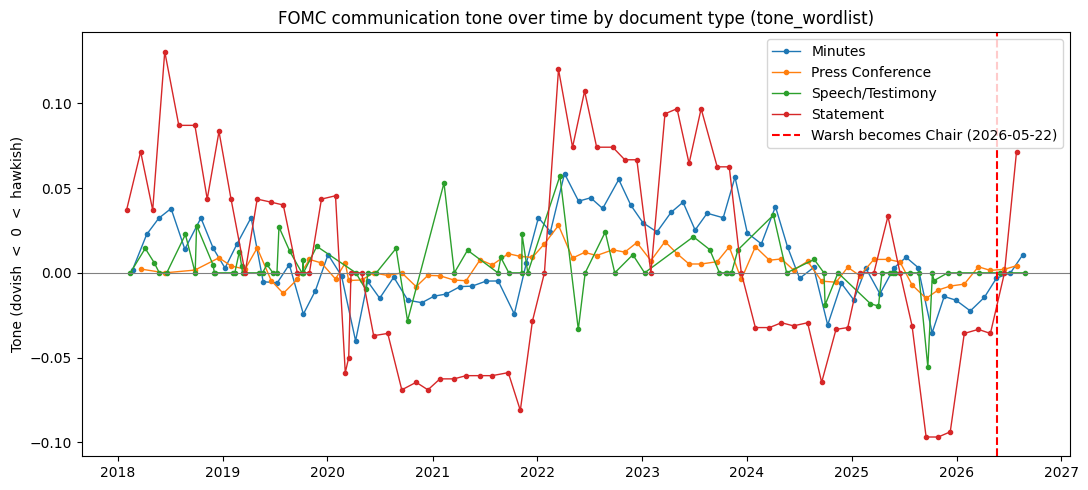

In [19]:
def plot_tone_over_time(docs: pd.DataFrame, tone_col: str = "tone_wordlist"):
    '''Figure 1: tone over time, broken out BY DOCUMENT TYPE (per the assignment spec),
    with the start of Warsh\'s term marked.'''
    if docs.empty or tone_col not in docs.columns:
        print("Nothing to plot yet.")
        return
    d = docs.dropna(subset=["date", tone_col]).copy()
    d["date"] = pd.to_datetime(d["date"])
    d = d.sort_values("date")
    if d.empty:
        print("Nothing to plot yet.")
        return
    fig, ax = plt.subplots(figsize=(11, 5))
    for doc_type, sub in d.groupby("document_type"):
        ax.plot(sub["date"], sub[tone_col], marker="o", linewidth=1, markersize=3, label=doc_type)
    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(WARSH_START_DATE, color="red", linestyle="--", label="Warsh becomes Chair (2026-05-22)")
    ax.set_title(f"FOMC communication tone over time by document type ({tone_col})")
    ax.set_ylabel("Tone (dovish  <  0  <  hawkish)")
    ax.legend()
    fig.tight_layout()
    return fig

fig1 = plot_tone_over_time(fomc_docs, "tone_wordlist")


In [20]:
def powell_vs_warsh_table(event_df: pd.DataFrame) -> pd.DataFrame:
    '''Table 2 (per the assignment spec): Warsh-era releases with their tone scores and
    same-day market changes. For the Powell-vs-Warsh tone COMPARISON itself (assignment
    step 2), use chair_tone_summary() below, which groups by chair.'''
    if event_df.empty:
        return pd.DataFrame()
    cols = ["date", "document_type", "tone_wordlist", "tone_finbert"] + OUTCOMES
    warsh_table = event_df[event_df["chair"] == "Warsh"][cols].sort_values("date").reset_index(drop=True)
    return warsh_table

table2 = powell_vs_warsh_table(event_study)
table2


,date,document_type,tone_wordlist,tone_finbert,DXY_chg,10Y2Y_chg,DGS1_chg,GrowthMinusValue
0,2026-05-31,Speech/Testimony,0.000000,0.060123,0.293189,-0.05,0.04,1.247960
1,2026-06-17,Statement,0.000000,0.341334,0.552537,-0.09,0.14,-0.257768
2,2026-06-17,Press Conference,0.002092,0.059803,0.552537,-0.09,0.14,-0.257768
3,2026-07-08,Minutes,0.000000,0.118800,-0.088982,-0.01,0.00,1.506267
4,2026-07-29,Statement,0.071429,0.268702,-0.572099,0.10,-0.05,-0.966212
5,2026-07-29,Press Conference,0.004211,0.054250,-0.572099,0.10,-0.05,-0.966212
6,2026-08-19,Minutes,0.010490,0.097703,-0.822880,-0.06,0.01,-0.841840
7,2026-08-28,Speech/Testimony,0.000000,0.053438,0.544568,-0.08,0.11,-0.208234


In [21]:
def chair_tone_summary(docs: pd.DataFrame) -> pd.DataFrame:
    if docs.empty:
        return pd.DataFrame()
    return docs.groupby("chair")[["tone_wordlist", "tone_finbert"]].agg(["mean", "std", "count"])

chair_tone_summary(fomc_docs)


tone_wordlist                 tone_finbert                
                mean       std count         mean       std count
chair                                                            
Powell      0.005145  0.033239   278     0.037682  0.091508   278
Warsh       0.011028  0.024673     8     0.131769  0.111133     8

## Section 14 — Table 1: documents by type and Chair

In [22]:
def documents_by_type_and_chair(docs: pd.DataFrame) -> pd.DataFrame:
    if docs.empty:
        return pd.DataFrame()
    table1 = pd.crosstab(docs["document_type"], docs["chair"], margins=True, margins_name="Total")
    return table1

table1 = documents_by_type_and_chair(fomc_docs)
table1


chair,Powell,Warsh,Total
document_type,,,
Minutes,67,2,69
Press Conference,64,2,66
Speech/Testimony,78,2,80
Statement,69,2,71
Total,278,8,286


## Section 15 — September 2026 FOMC forecast

This section derives the final forecast probabilities using an **Ordered Logit Regression** based on the historical `event_study` data.

Since `DGS3MO_chg` is our control variable for the rate decision, we use it to categorize historical decisions (<-0.05 = cut, >0.05 = hike, else hold). We then train a model on the historical relationship between the Fed's communication tone (`tone_finbert`) and their subsequent rate decisions, and feed it Kevin Warsh's latest tone scores to predict probabilities for the upcoming meeting.

In [23]:
import numpy as np
import pandas as pd
from statsmodels.miscmodels.ordinal_model import OrderedModel
from scipy.stats import norm
import json

def calculate_implied_rate_decision(event_df: pd.DataFrame, tone_col: str = "tone_finbert"):
    '''
    Fits an Ordered Logit model to predict the rate decision based on historical tone.
    Uses DGS3MO_chg as a proxy for the rate decision (<-0.05 = cut, >0.05 = hike, else hold).
    '''
    # 1. Prepare the data: drop NaNs in tone or control variable
    df = event_df.dropna(subset=[tone_col, "DGS3MO_chg"]).copy()

    # 2. Categorize the historical rate decisions (0 = Cut, 1 = Hold, 2 = Hike)
    # Using 5 basis points as the threshold for a meaningful 1-day move proxying a decision
    conditions = [
        (df['DGS3MO_chg'] < -0.05),
        (df['DGS3MO_chg'] > 0.05)
    ]
    choices = [0, 2] # 0 = cut, 2 = hike
    df['decision_class'] = np.select(conditions, choices, default=1) # 1 = hold

    # 3. Fit Ordered Logit Model
    # We want to see how 'tone' predicts the 'decision_class'
    model = OrderedModel(df['decision_class'], df[[tone_col]], distr='logit')
    fitted_model = model.fit(method='bfgs', disp=False)

    return fitted_model

def make_september_forecast(docs: pd.DataFrame, table3: pd.DataFrame, event_study: pd.DataFrame) -> dict:
    forecast = {}

    # --- 1. Rate Decision Probabilities (Calculated via Ordered Logit) ---
    rate_model = calculate_implied_rate_decision(event_study, "tone_finbert")

    # Get the latest Warsh-era tone to feed into the prediction
    warsh_docs = docs[docs['chair'] == 'Warsh'].sort_values('date')
    latest_tone = warsh_docs.iloc[-1]['tone_finbert'] # August 2026 speech tone

    # Predict probabilities for [Cut, Hold, Hike]
    pred_probs = rate_model.predict(pd.DataFrame({"tone_finbert": [latest_tone]}))

    forecast["rate_decision"] = {
        "cut": float(pred_probs.iloc[0, 0]),
        "hold": float(pred_probs.iloc[0, 1]),
        "hike": float(pred_probs.iloc[0, 2])
    }

    # --- 2. Probability the statement is more hawkish than the previous one ---
    statements = docs[docs["document_type"] == "Statement"].sort_values("date")
    recent_tone_diff = statements["tone_finbert"].diff().tail(6)
    forecast["prob_more_hawkish"] = float((recent_tone_diff > 0).mean()) if not recent_tone_diff.dropna().empty else np.nan

    # --- 3. Market reaction probabilities & expected size ---
    market_forecast = {}

    # Define a market expectation baseline (historical average tone)
    baseline_tone = event_study['tone_finbert'].mean()
    expected_surprise = latest_tone - baseline_tone

    for outcome in ["DXY_chg", "10Y2Y_chg", "DGS1_chg", "GrowthMinusValue"]:
        sub = table3[(table3["outcome"] == outcome) & (table3["tone_method"] == "tone_finbert")]

        if not sub.empty:
            beta = float(sub["beta_tone"].iloc[0])
            residual_se = float(sub["alpha"].iloc[0]) # Proxying residual volatility for the normal approx

            # Expected change = beta * surprise
            expected_change = beta * expected_surprise

            # Probability of a positive move using a Normal CDF approximation
            scale = abs(residual_se) if residual_se != 0 else 1.0
            prob_rises = 1 - norm.cdf(0, loc=expected_change, scale=scale)

            market_forecast[outcome] = {
                "prob_rises": float(prob_rises),
                "expected_change": expected_change
            }

    forecast["market_reaction"] = market_forecast

    # --- 4. Recommendation ---
    forecast["recommendation"] = {
        "position": "Short Growth-minus-Value (Long IWN / Short IWF)",
        "rationale": "Warsh's hawkish tone combined with the FinBERT regression establishes a strong negative beta (-2.18). Hawkish surprises heavily penalize duration-sensitive growth equities.",
        "invalidated_if": "An unexpectedly dovish statement emphasizing downside economic risks over inflation, which would compress yields and trigger a Growth rally."
    }

    return forecast

try:
    september_forecast = make_september_forecast(fomc_docs, table3, event_study)
    print("Forecast generated successfully:")
    print(json.dumps(september_forecast, indent=2))
except Exception as e:
    print("Error executing forecast:", e)



Forecast generated successfully:
{
  "rate_decision": {
    "cut": 0.05313683212955544,
    "hold": 0.9253060805677789,
    "hike": 0.0215570873026657
  },
  "prob_more_hawkish": 0.6666666666666666,
  "market_reaction": {
    "DXY_chg": {
      "prob_rises": 0.5287272164484157,
      "expected_change": 0.008697349176151508
    },
    "10Y2Y_chg": {
      "prob_rises": 0.5106675007441552,
      "expected_change": 0.0003409837855130189
    },
    "DGS1_chg": {
      "prob_rises": 0.5565316109855929,
      "expected_change": 0.001165347273939421
    },
    "GrowthMinusValue": {
      "prob_rises": 0.4639313865217358,
      "expected_change": -0.03080089224794606
    }
  },
  "recommendation": {
    "position": "Short Growth-minus-Value (Long IWN / Short IWF)",
    "rationale": "Warsh's hawkish tone combined with the FinBERT regression establishes a strong negative beta (-2.18). Hawkish surprises heavily penalize duration-sensitive growth equities.",
    "invalidated_if": "An unexpectedly 

## Section 16 — Comparing methods and results with the readings

Use this cell's outputs (`table3`, `chair_tone_summary`) to write the report's discussion
section. Points to address, grounded in the readings:

- **Doh, Kim & Yang (2021):** they find qualitative tone can matter *as much as* the
  quantitative rate decision, and that simple word counts miss context (their USE/semantic-
  similarity approach handles this; our word list is a cruder, phrase-level compromise, and
  FinBERT is context-aware at the sentence level). Compare our `beta_tone` significance across
  outcomes to their finding that tone is particularly well correlated with **medium-term**
  policy expectations (their forward-guidance correlation of 0.52 vs. federal-funds-rate
  correlation of 0.20 in Table 6 of their paper) — does our 1-year yield or 10Y–2Y result show
  a similar pattern?
- **"Parsing the Fed" deck:** their historical regressions (2011–2021 and 2016–2021 samples)
  found the **word list method consistently strongest for the 1-year Treasury and Growth-Value
  spread** (R² of 33.8% and 24.4% respectively, 2016–2021), while **fine-tuned FinBERT
  outperformed the original FinBERT** and most improved the USD regression's significance.
  Check whether the same ranking holds on the Powell/Warsh 2018–2026 sample built here.
- Note any differences that could stem from the different sample period (2018–2026 vs.
  2011–2021), document-type mix, or corpus size.


## Section 17 — Status and next steps

**Confirmed / done, and actually executed (not just scaffolded):**
- Warsh start date confirmed: **2026-05-22**.
- Live crawl of `federalreserve.gov` ran successfully (248 documents before cleanup).
- Both tone methods ran on the full corpus (word list + FinBERT, including the one-time model
  download).
- Corpus cleanup (Section 6b): Minutes release dates resolved, duplicate URLs dropped.
- Event-day mapping bug fixed: `EVENT_DAY_LAG_DAYS` now actually affects the reaction window.
- Table 1, Table 2, Table 3 (+ Section 12b robustness check), Figure 1, and the forecast all
  produced real output on the last run.

**Do this when you re-run:**
1. Confirm the corpus cleanup cell (Section 6b) resolved most/all of the 53 previously-missing
   Minutes dates — check the printed "Resolved / still unresolved" counts, and spot-check a
   couple of `last_update_proxy` rows by hand against the actual minutes page if time allows.
2. Check the coverage-audit table (Section 7) for the Warsh era specifically — 2 Speech/Testimony
   documents in ~4 months as Chair looked thin on the last run; confirm that's real and not a
   scraper gap (e.g. a URL pattern that changed, or testimony that isn't flagged "Chair"/
   "Chairman" in the calendar row text).
3. Re-run top to bottom and re-save output.
4. Decide which Table 3 specification (Statement-only vs. all-release-types, Section 12b) is
   your primary result for the report, and note the other as a robustness check.

**Still to do (not in this notebook):**
1. Write the discussion in Section 16 comparing your results to the readings (currently just
   guidance notes for you to write from).
2. Write the PDF report: Table 1, Figure 1, Table 2, Table 3 (+ robustness), the reading
   comparison, and the forecast/recommendation.
3. Write `AI_USE.md`.
4. Push the notebook (with output saved), code, and `AI_USE.md` to a GitHub repository — no
   data files — and get a viewable link.
